## FaceVault — Building a Face Recognition System with Subspace Methods

### The Scenario

You've just joined **FaceVault**, a security startup building an identity verification system for enterprise access control.  
Your task: recognise employees from face images — even under different lighting, slight pose changes, or low-resolution scans.

Raw pixel matching fails immediately — two photos of the same person can be farther apart in pixel space than photos of different people with similar lighting.  
Your manager says: *"We need to work in a smarter space — one where faces of the same person cluster together."*

This is where subspace methods come in: PCA (Eigenfaces) and LDA (Fisherfaces).

📖 **Background Reading — Start Here:**
- [Eigenfaces Explained — Towards Data Science](https://towardsdatascience.com/an-attempt-to-fine-tune-facial-recognition-eigenfaces-a6baa8fc0e62/)
- [Eigenfaces, Fisherfaces & LBPH — Seymur Qaribov](https://medium.com/@seymurqribov05/face-recognition-eigenfaces-fisherfaces-lbph-0b39d41bd54c)
- [Recovering Humans from Ghosts — Data Science Blog](https://medium.com/data-science/eigenfaces-recovering-humans-from-ghosts-17606c328184)

---

### Dataset
**Labeled Faces in the Wild (LFW)** — loaded directly via `sklearn.datasets`  
A real-world benchmark of celebrity/public-figure face images collected from the web.  

---  

### Notebook Breakdown

| Part | Topic |
|---|---|
| A | Data Exploration |
| B | PCA — Eigenfaces |
| C | Reconstruction Analysis |
| D | PCA-Based Classification |
| E | LDA — Fisherfaces |
| F | PCA vs LDA Comparison |


### ⚙️ Setup — Run this first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import seaborn as sns

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

print('Setup complete.')


Setup complete.


---
## Part A — Data Exploration

> **Goal:** Understand what we're working with before building anything.

📖 [An attempt to fine-tune facial recognition – Eigenfaces — Towards Data Science](https://towardsdatascience.com/an-attempt-to-fine-tune-facial-recognition-eigenfaces-a6baa8fc0e62/)

**Key Concept — The Curse of Dimensionality:**  
Each face image is a point in a *D*-dimensional space (here D ≈ 62x47 = 2,914). In such high dimensions:
- Distance measures become unreliable — all points appear roughly equidistant
- We need exponentially more data to cover the space
- Raw pixel similarity doesn't correlate well with identity

The insight of subspace methods is that faces don't live in all of ℝᴰ — they lie on a **low-dimensional subspace**.


In [4]:
# Load LFW — only people with ≥70 images for a balanced, manageable subset
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.5)

X = lfw.data          # shape: (n_samples, n_features)
y = lfw.target        # integer class labels
names = lfw.target_names  # person names
h, w = lfw.images.shape[1], lfw.images.shape[2]  # image height, width

n_samples, n_features = X.shape
n_classes = len(names)

print('=' * 50)
print(f'  LFW Dataset Summary')
print('=' * 50)
print(f'  Samples    : {n_samples}')
print(f'  Features   : {n_features}  ({h} x {w} pixels)')
print(f'  Classes    : {n_classes}')
print(f'  Names      : {list(names)}')
print('=' * 50)


  LFW Dataset Summary
  Samples    : 1288
  Features   : 2914  (62 x 47 pixels)
  Classes    : 7
  Names      : [np.str_('Ariel Sharon'), np.str_('Colin Powell'), np.str_('Donald Rumsfeld'), np.str_('George W Bush'), np.str_('Gerhard Schroeder'), np.str_('Hugo Chavez'), np.str_('Tony Blair')]


In [9]:
import numpy as np
from collections import Counter

max_per_class = 150
balanced_indices = []

for class_id in np.unique(y):
    class_indices = np.where(y == class_id)[0]

    if len(class_indices) > max_per_class:
        selected = np.random.choice(class_indices,
                                    max_per_class,
                                    replace=False)
    else:
        selected = class_indices

    balanced_indices.extend(selected)

balanced_indices = np.array(balanced_indices)

X = X[balanced_indices]
y = y[balanced_indices]

print("New dataset shape:", X_bal.shape)
print("New class distribution:", Counter(y_bal))

New dataset shape: (822, 2914)
New class distribution: Counter({np.int64(1): 150, np.int64(3): 150, np.int64(6): 144, np.int64(2): 121, np.int64(4): 109, np.int64(0): 77, np.int64(5): 71})


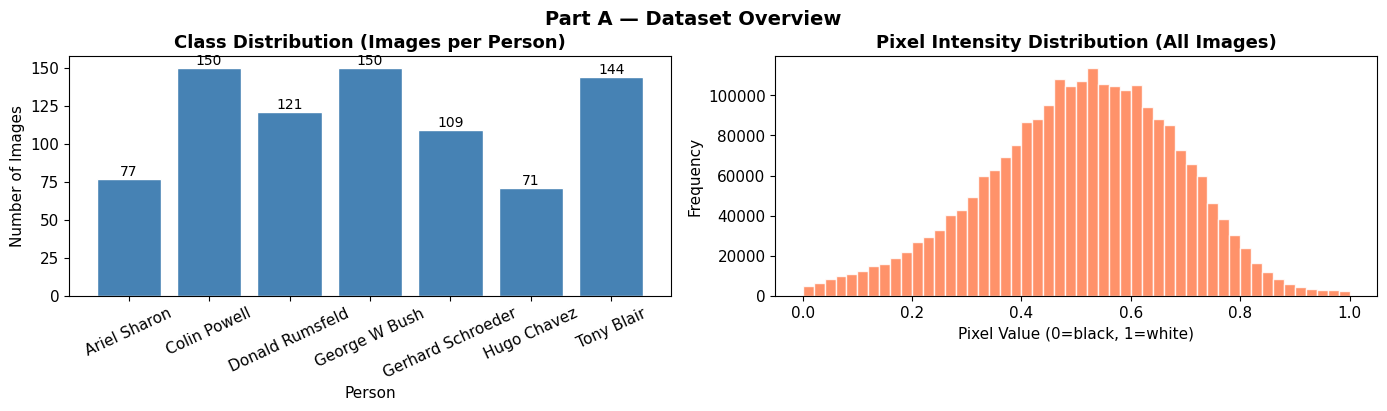

Pixel stats → Mean: 0.509  |  Std: 0.174  |  Min: 0.000  |  Max: 1.000


In [10]:
# A1 — Class distribution
counts = np.bincount(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
axes[0].bar(names, counts, color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution (Images per Person)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Person')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=25)
for i, c in enumerate(counts):
    axes[0].text(i, c + 2, str(c), ha='center', fontsize=10)

# Pixel intensity distribution
axes[1].hist(X.flatten(), bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Pixel Intensity Distribution (All Images)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pixel Value (0=black, 1=white)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Part A — Dataset Overview', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print(f'Pixel stats → Mean: {X.mean():.3f}  |  Std: {X.std():.3f}  |  Min: {X.min():.3f}  |  Max: {X.max():.3f}')


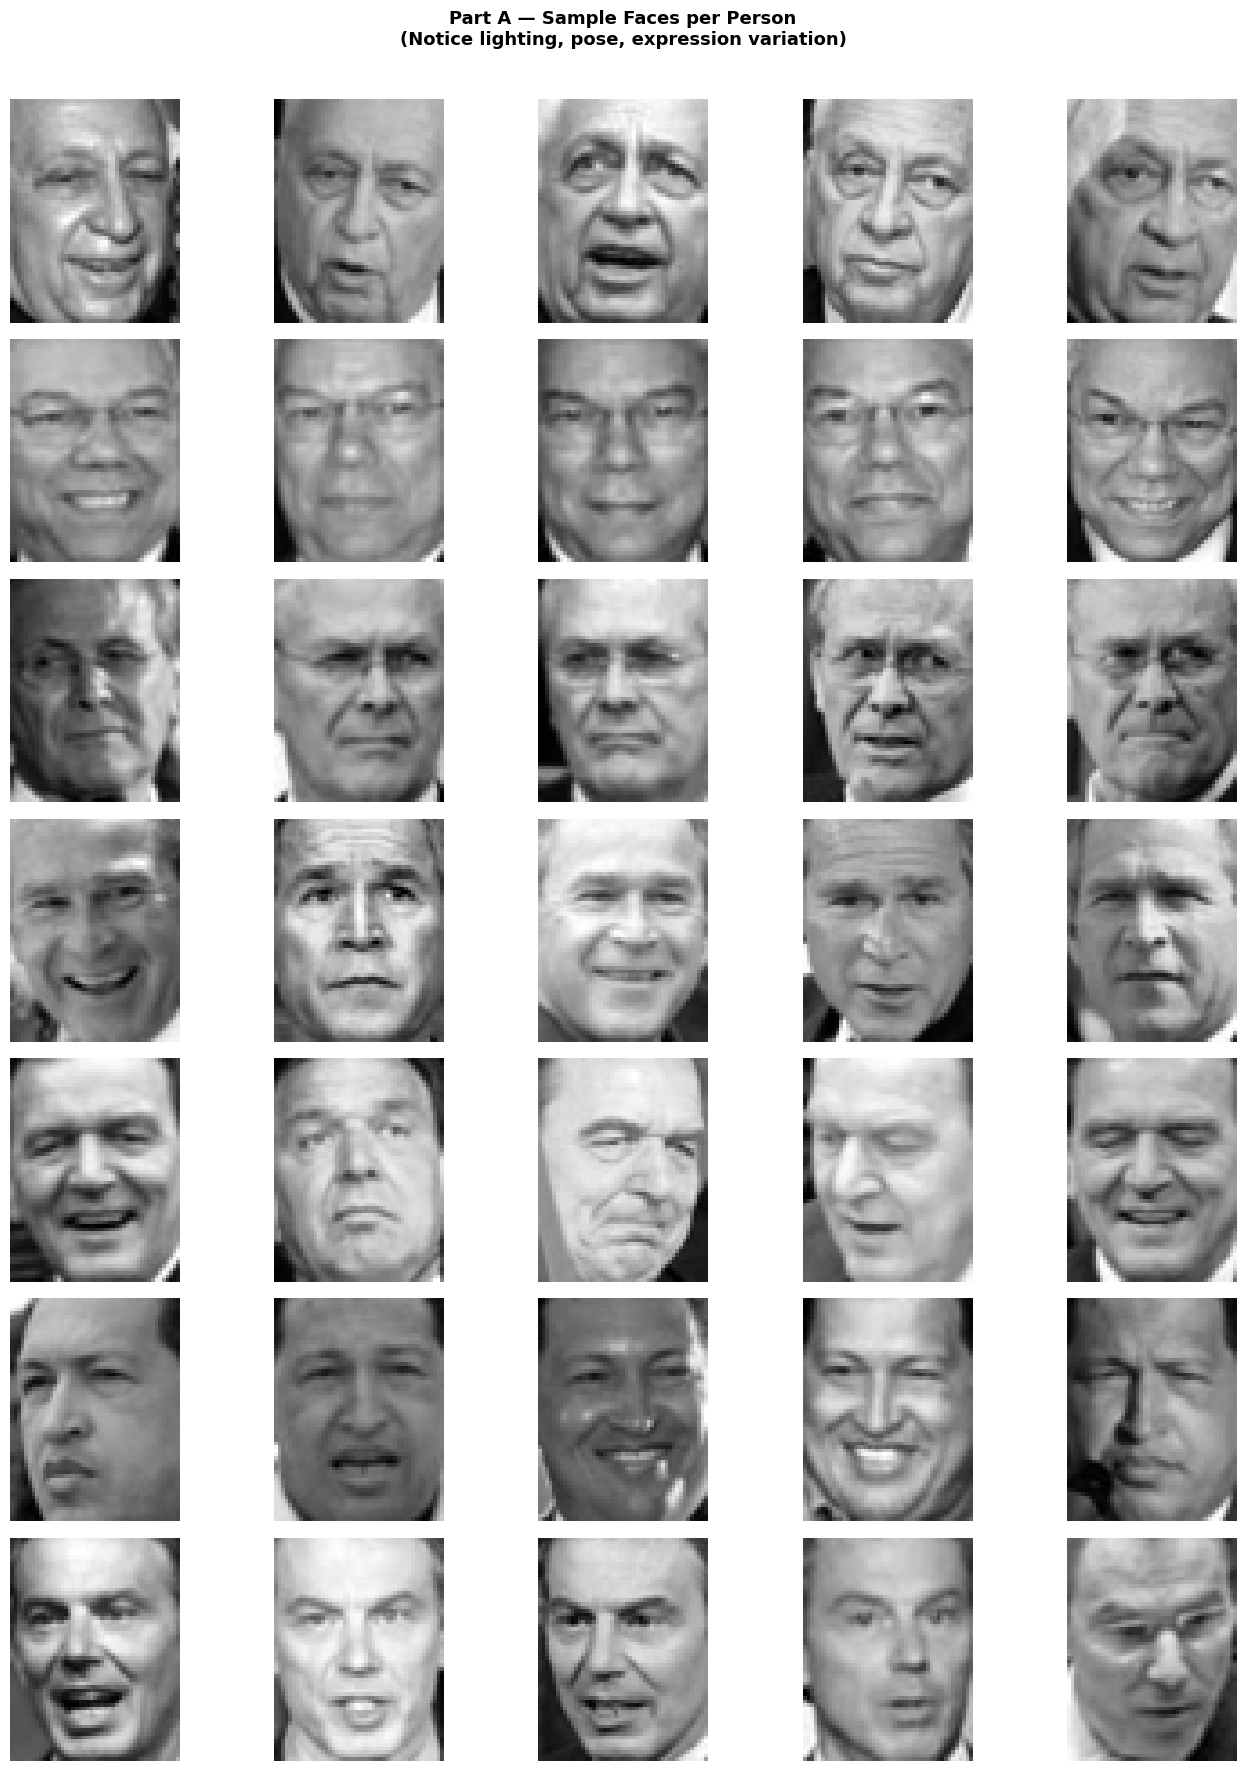

In [12]:
# A2 — Display sample faces for each person
fig, axes = plt.subplots(n_classes, 5, figsize=(14, n_classes * 2.5))
fig.suptitle('Part A — Sample Faces per Person\n(Notice lighting, pose, expression variation)',
             fontsize=13, fontweight='bold', y=1.01)

for cls_idx in range(n_classes):
    class_images = X[y == cls_idx].reshape(-1, h, w)
    for j in range(5):
        ax = axes[cls_idx, j]
        ax.imshow(class_images[j], cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(names[cls_idx].split()[-1], rotation=0, labelpad=55,
                          fontsize=10, fontweight='bold', va='center')

plt.tight_layout()
plt.show()

#### 📝 Part A — Conceptual Questions

**Q1.** Why is face recognition challenging in high-dimensional pixel space?  
*(Hint: Think about distance concentration, intra-class vs inter-class variation, and the curse of dimensionality.)*


**A1.** *(Write your answer here)*

...


**Q2.** Why might raw Euclidean distance fail for face classification?  
*(Hint: Consider two photos of the same person — one in bright light, one in shadow. What does pixel-level L2 distance actually measure?)*


**A2.** *(Write your answer here)*

...


In [13]:
# Train / test split — we'll reuse this split throughout the notebook
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')


Train: 616 samples  |  Test: 206 samples


---
## Part B — Principal Component Analysis (Eigenfaces)

> **Goal:** Find the directions of maximum variance in face space.

📖 [A One-Stop Shop for Principal Component Analysis](https://towardsdatascience.com/a-one-stop-shop-for-principal-component-analysis-5582fb7e0a9c/)  
📖 [StatQuest: PCA Step-by-Step (YouTube)](https://www.youtube.com/watch?v=FgakZw6K1QQ)  
📖 [PCA — Scikit-learn User Guide](https://scikit-learn.org/stable/modules/decomposition.html#pca)

### Theory — How PCA Works

Given a data matrix **X** (n × D, mean-centred), PCA solves:

$$\text{Maximize } \mathbf{w}^\top \mathbf{C} \mathbf{w} \quad \text{subject to } \|\mathbf{w}\| = 1$$

where **C** = (1/n) **XᵀX** is the covariance matrix.  
The solutions are the **eigenvectors** of **C**, ordered by their **eigenvalues** (= variance explained).

When reshaped back to image size, these eigenvectors become the **Eigenfaces** — the principal "modes of variation" across all training faces.

**Key intuitions:**
- Eigenface 1 captures the direction of *greatest* variance (usually global lighting)
- Later eigenfaces capture finer details (eyes, nose, wrinkles…)
- Eigenvectors are orthogonal, hence there is no redundant information between components


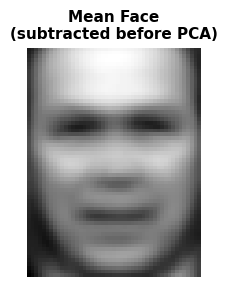

PCA fitted.  Components: 150  |  Variance explained by all: 94.8%


In [14]:
# B1 — Compute PCA (fit on training data only!)
N_COMPONENTS_FULL = 150  # upper bound for analysis

pca = PCA(n_components=N_COMPONENTS_FULL, whiten=True, random_state=42)
pca.fit(X_train)

# Mean face
mean_face = pca.mean_.reshape(h, w)

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(mean_face, cmap='gray')
ax.set_title('Mean Face\n(subtracted before PCA)', fontsize=11, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'PCA fitted.  Components: {pca.n_components_}  |  '
      f'Variance explained by all: {pca.explained_variance_ratio_.sum()*100:.1f}%')


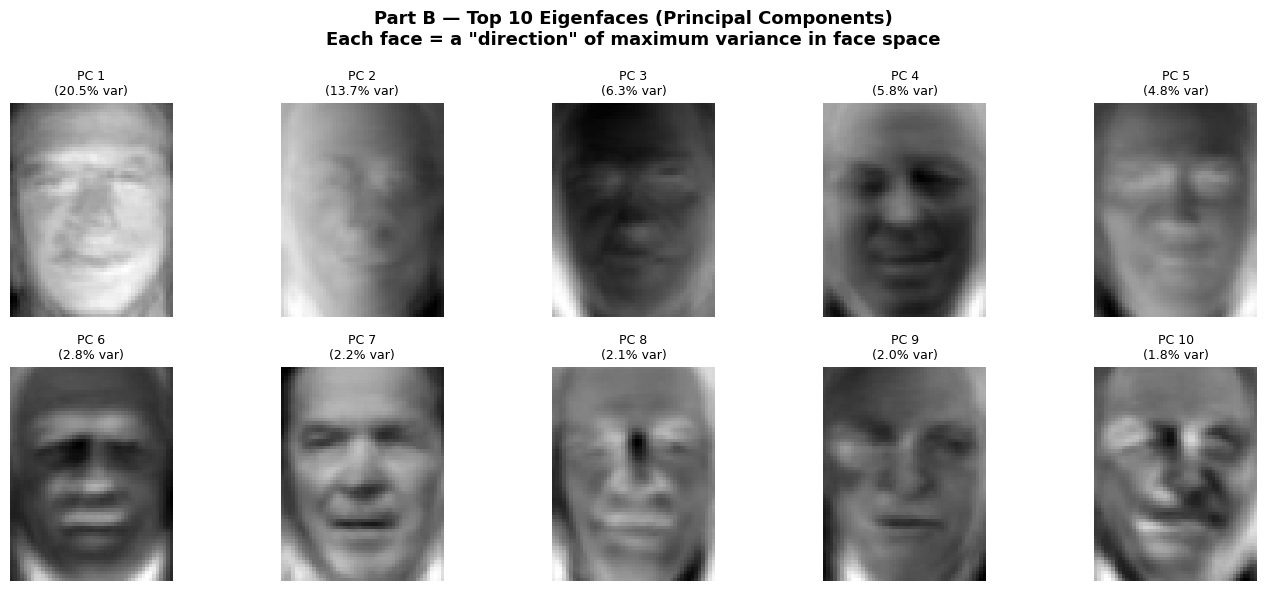

In [15]:
# B2 — Visualize top 10 Eigenfaces
n_show = 10
eigenfaces = pca.components_[:n_show].reshape(n_show, h, w)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Part B — Top 10 Eigenfaces (Principal Components)\n'
             'Each face = a "direction" of maximum variance in face space',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # Normalise each eigenface for display
    ef = eigenfaces[i]
    ef_display = (ef - ef.min()) / (ef.max() - ef.min())
    ax.imshow(ef_display, cmap='gray')
    var = pca.explained_variance_ratio_[i] * 100
    ax.set_title(f'PC {i+1}\n({var:.1f}% var)', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


#### 📝 Part B — Conceptual Questions

**Q3.** Why do eigenfaces look "ghost-like" or eerie rather than clean portraits?


**A3.** *(Write your answer here)*

...


**Q4.** Why do the top eigenfaces often seem to capture lighting patterns (bright vs dark half)?  
*(Hint: Which feature causes the most pixel-level variance across a dataset of face photos?)*


**A4.** *(Write your answer here)*

...


**Q5.** Why are eigenvectors guaranteed to be orthogonal?  
*(Hint: Think about the covariance matrix being real and symmetric.)*


**A5.** *(Write your answer here)*

...


---
## Part C — Reconstruction Analysis

> **Goal:** Understand how many components you actually need.

📖 [Image Compression with PCA — Towards Data Science](https://towardsdatascience.com/image-compression-using-principal-component-analysis-pca-253f26740a9f/)

### Theory — Image Reconstruction

A face **x** can be approximated using *k* eigenfaces:

$$\hat{\mathbf{x}}_k = \bar{\mathbf{x}} + \sum_{i=1}^{k} (\mathbf{x} \cdot \mathbf{u}_i)\, \mathbf{u}_i$$

where **ū** is the mean face and **uᵢ** are the top-k eigenvectors.  
The projection of a face onto eigenface *i* gives a single scalar coefficient — its weight along that direction.  
More components implies more detail recovered from the original image.


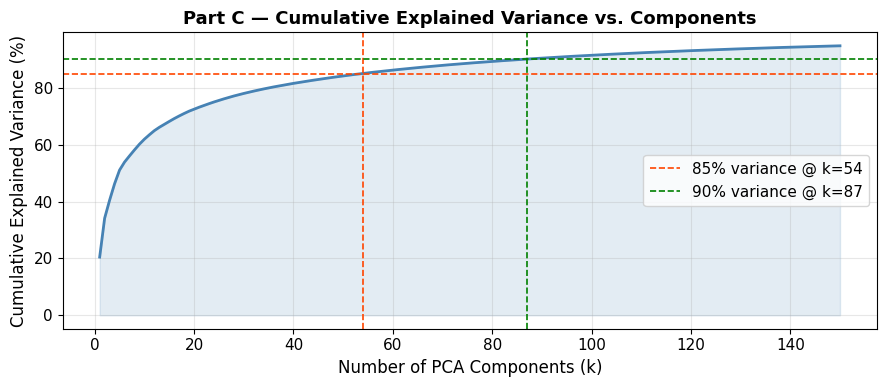

  85% variance retained with k = 54 components
  90% variance retained with k = 87 components


In [16]:
# C1 — Cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, color='steelblue', linewidth=2)
ax.fill_between(range(1, len(cumvar)+1), cumvar, alpha=0.15, color='steelblue')

# Mark 90% and 95% thresholds
for thresh, col in [(85, 'orangered'), (90, 'green')]:
    if (cumvar >= thresh).any():
        k_thresh = np.argmax(cumvar >= thresh) + 1
        ax.axhline(thresh, color=col, linestyle='--', linewidth=1.2,
                   label=f'{thresh}% variance @ k={k_thresh}')
        ax.axvline(k_thresh, color=col, linestyle='--', linewidth=1.2)
    else:
        ax.axhline(thresh, color=col, linestyle=':', linewidth=1.2,
                   label=f'{thresh}% variance — not reached in {N_COMPONENTS_FULL} components')

ax.set_xlabel('Number of PCA Components (k)', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_title('Part C — Cumulative Explained Variance vs. Components', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for thresh in [85, 90]:
    k = np.argmax(cumvar >= thresh) + 1
    print(f'  {thresh}% variance retained with k = {k} components')


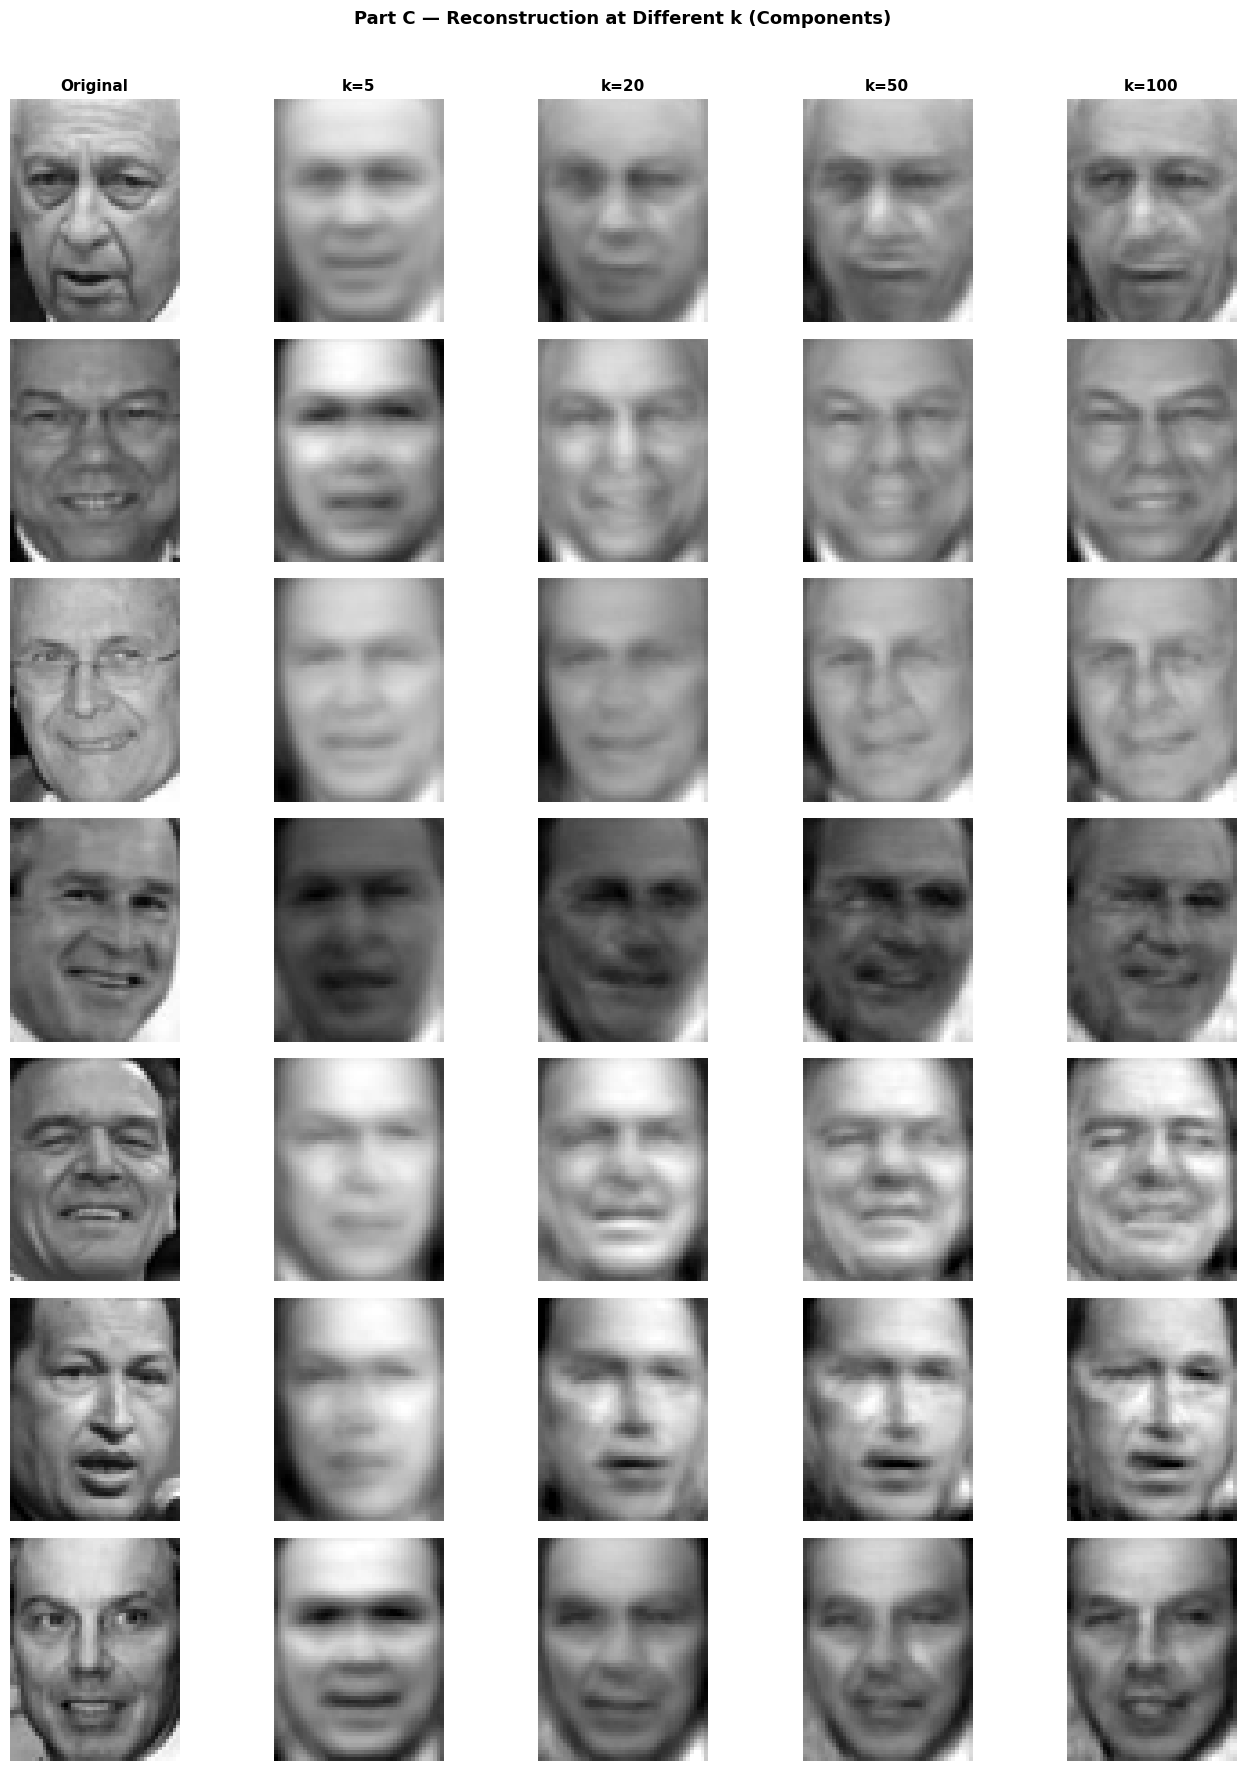

In [18]:
# C2 — Reconstruct a test face at different k values
def reconstruct_face(x, pca_model, k):
    """Project x into k-component PCA space and reconstruct."""
    x_centered = x - pca_model.mean_
    components_k = pca_model.components_[:k]  # (k, D)
    coeffs = x_centered @ components_k.T       # (k,)
    reconstructed = pca_model.mean_ + coeffs @ components_k
    return reconstructed

k_values = [5, 20, 50, 100]
# Pick one test face from each class
sample_idx = [np.where(y_test == c)[0][0] for c in range(n_classes)]

fig, axes = plt.subplots(n_classes, len(k_values)+1, figsize=(14, n_classes*2.5))
fig.suptitle('Part C — Reconstruction at Different k (Components)',
             fontsize=13, fontweight='bold', y=1.01)

col_titles = ['Original'] + [f'k={k}' for k in k_values]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')

for row, idx in enumerate(sample_idx):
    x_orig = X_test[idx]
    # Original
    axes[row, 0].imshow(x_orig.reshape(h, w), cmap='gray')
    axes[row, 0].set_ylabel(names[y_test[idx]].split()[-1], rotation=0,
                             labelpad=55, fontsize=9, fontweight='bold', va='center')
    axes[row, 0].axis('off')
    # Reconstructions
    for col, k in enumerate(k_values):
        rec = reconstruct_face(x_orig, pca, k).reshape(h, w)
        rec_clipped = np.clip(rec, 0, 1)
        axes[row, col+1].imshow(rec_clipped, cmap='gray')
        mse = np.mean((x_orig.reshape(h, w) - rec_clipped)**2)
        axes[row, col+1].set_xlabel(f'MSE={mse:.4f}', fontsize=8)
        axes[row, col+1].axis('off')

plt.tight_layout()
plt.show()


#### 📝 Part C — Conceptual Questions

**Q6.** Why does reconstruction quality improve *non-linearly* as k increases?  
*(Hint: Look at the explained variance of individual components — how much does PC1 explain vs PC50?)*


**A6.** *(Write your answer here)*

...


**Q7.** Why might retaining **100% variance** (i.e., using all components) be undesirable for classification?  
*(Hint: Think noise, and what the last few principal components typically capture.)*


**A7.** *(Write your answer here)*

...


---
## Part D — PCA-Based Classification (k-NN in Eigenspace)

> **Goal:** Test whether projecting into PCA space actually helps face identification.

📖 [PCA for Face Recognition — OpenCV Docs](https://docs.opencv.org/4.x/da/d60/tutorial_face_main.html)

### Strategy
1. Project training and test faces into PCA subspace
2. Train a k-NN classifier in that reduced space
3. Sweep over different numbers of PCA components
4. Also sweep over k in k-NN

**Baseline first** — always compare against raw pixels.


In [19]:
# D1 — Baseline: k-NN on raw pixels (no dimensionality reduction)
knn_raw = KNeighborsClassifier(n_neighbors=3)
knn_raw.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, knn_raw.predict(X_test))
print(f'Baseline accuracy (k-NN on raw pixels, k=3): {baseline_acc*100:.1f}%')
print(f'(Feature dimensionality: {X_train.shape[1]})')


Baseline accuracy (k-NN on raw pixels, k=3): 46.6%
(Feature dimensionality: 2914)


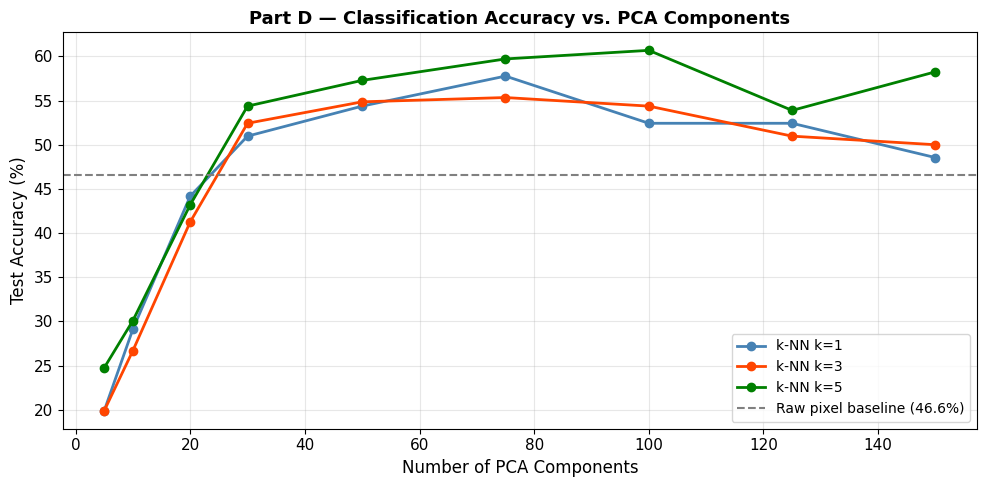

Best PCA-kNN: k=5, n_components=100, accuracy=60.7%


In [20]:
# D2 — Sweep: PCA components x k-NN neighbours
component_range = [5, 10, 20, 30, 50, 75, 100, 125, 150]
knn_k_range = [1, 3, 5]

results = {}
for knn_k in knn_k_range:
    accs = []
    for n_comp in component_range:
        pipe = Pipeline([
            ('pca', PCA(n_components=n_comp, whiten=True, random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=knn_k))
        ])
        pipe.fit(X_train, y_train)
        accs.append(accuracy_score(y_test, pipe.predict(X_test)))
    results[knn_k] = accs

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue', 'orangered', 'green']
for (knn_k, accs), col in zip(results.items(), colors):
    ax.plot(component_range, [a*100 for a in accs], marker='o',
            label=f'k-NN k={knn_k}', color=col, linewidth=2)

ax.axhline(baseline_acc*100, color='gray', linestyle='--', linewidth=1.5, label=f'Raw pixel baseline ({baseline_acc*100:.1f}%)')
ax.set_xlabel('Number of PCA Components', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Part D — Classification Accuracy vs. PCA Components', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print best result
best_k = min(results, key=lambda k: -max(results[k]))
best_comp = component_range[np.argmax(results[best_k])]
best_acc = max(results[best_k])
print(f'Best PCA-kNN: k={best_k}, n_components={best_comp}, accuracy={best_acc*100:.1f}%')


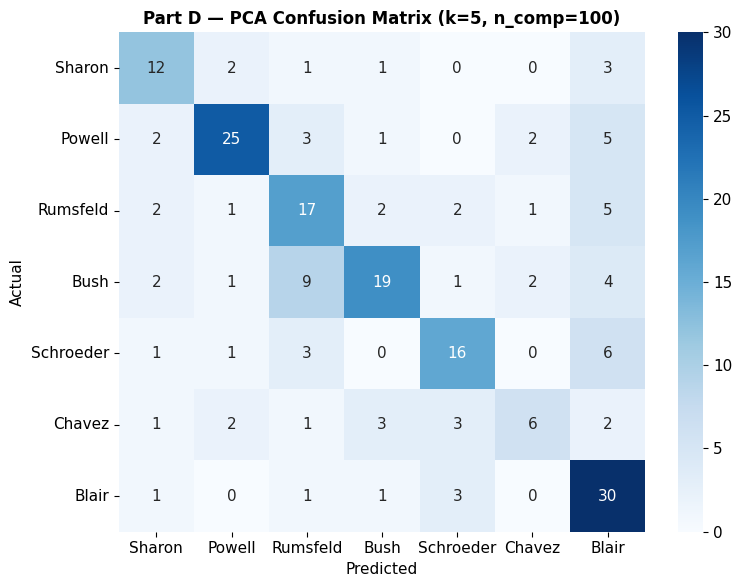

              precision    recall  f1-score   support

      Sharon       0.57      0.63      0.60        19
      Powell       0.78      0.66      0.71        38
    Rumsfeld       0.49      0.57      0.52        30
        Bush       0.70      0.50      0.58        38
   Schroeder       0.64      0.59      0.62        27
      Chavez       0.55      0.33      0.41        18
       Blair       0.55      0.83      0.66        36

    accuracy                           0.61       206
   macro avg       0.61      0.59      0.59       206
weighted avg       0.62      0.61      0.60       206



In [21]:
# D3 — Confusion matrix for best PCA configuration
best_pipe = Pipeline([
    ('pca', PCA(n_components=best_comp, whiten=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])
best_pipe.fit(X_train, y_train)
y_pred_pca = best_pipe.predict(X_test)

cm_pca = confusion_matrix(y_test, y_pred_pca)
short_names = [n.split()[-1] for n in names]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_title(f'Part D — PCA Confusion Matrix (k={best_k}, n_comp={best_comp})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_pca, target_names=short_names))


#### 📝 Part D — Conceptual Questions

**Q8.** Why does classification accuracy **not always increase** as we add more PCA components?  
*(Hint: What do the later principal components primarily capture?)*


**A8.** *(Write your answer here)*

...


---
## Part E — Linear Discriminant Analysis (Fisherfaces)

> **Goal:** Use class label information to find directions that *separate* faces, not just vary them.

📖 [LDA — Sebastien Raschka's Tutorial](https://sebastianraschka.com/Articles/2014_python_lda.html)  
📖 [Fisherfaces Paper (Belhumeur et al. 1997)](https://cseweb.ucsd.edu/classes/wi14/cse152-a/fisherface-pami97.pdf)

### Theory — How LDA Works

LDA finds a projection **W** that simultaneously:
- **Maximises** between-class scatter $S_B$ (push different classes apart)
- **Minimises** within-class scatter $S_W$ (pull same-class samples together)

$$\text{Maximize} \quad J(\mathbf{W}) = \frac{|\mathbf{W}^\top S_B \mathbf{W}|}{|\mathbf{W}^\top S_W \mathbf{W}|}$$

Solved as a **generalized eigenvalue problem**: $S_B \mathbf{w} = \lambda S_W \mathbf{w}$

**Critical constraint:** LDA can extract at most **(C − 1)** discriminant directions, where C = number of classes.  
*(Because $S_B$ has rank at most C−1.)*

**Practical note:** Since D >> n in face datasets, $S_W$ is singular. The standard fix is to **first reduce with PCA**, then apply LDA — this is the "Fisherfaces" method.


In [22]:
# E1 — PCA + LDA pipeline (Fisherfaces approach)
# Step 1: Reduce to n-1 dimensions with PCA first (avoids singular Sw)
n_pca_for_lda = min(n_samples - n_classes, 100)
pca_for_lda = PCA(n_components=n_pca_for_lda, whiten=True, random_state=42)
X_train_pca = pca_for_lda.fit_transform(X_train)
X_test_pca  = pca_for_lda.transform(X_test)

# Step 2: LDA on PCA-reduced space
lda = LDA()
X_train_lda = lda.fit_transform(X_train_pca, y_train)
X_test_lda  = lda.transform(X_test_pca)

print(f'PCA reduced to {n_pca_for_lda} dims, '
      f'LDA reduced to {X_train_lda.shape[1]} dims  (max = C-1 = {n_classes-1})')


PCA reduced to 100 dims, LDA reduced to 6 dims  (max = C-1 = 6)


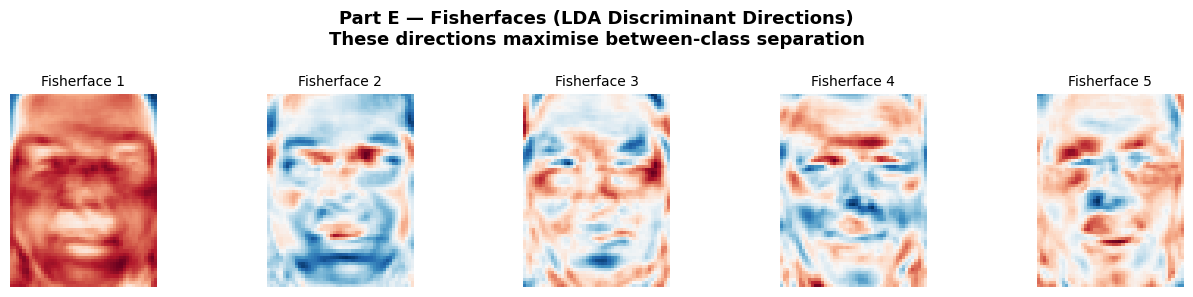

In [23]:
# E2 — Visualize Fisherfaces (LDA components reshaped to image space)
# The LDA scalings live in the PCA-reduced space; map them back to pixel space
# fisherface_i = pca_components.T @ lda_scalings_i
n_fisherfaces = min(n_classes - 1, 5)
fisherfaces_pixel = pca_for_lda.components_.T @ lda.scalings_[:, :n_fisherfaces]  # (D, n_fisher)

fig, axes = plt.subplots(1, n_fisherfaces, figsize=(13, 3))
fig.suptitle('Part E — Fisherfaces (LDA Discriminant Directions)\n'
             'These directions maximise between-class separation',
             fontsize=13, fontweight='bold')
for i, ax in enumerate(axes):
    ff = fisherfaces_pixel[:, i].reshape(h, w)
    ff_disp = (ff - ff.min()) / (ff.max() - ff.min())
    ax.imshow(ff_disp, cmap='RdBu_r')
    ax.set_title(f'Fisherface {i+1}', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


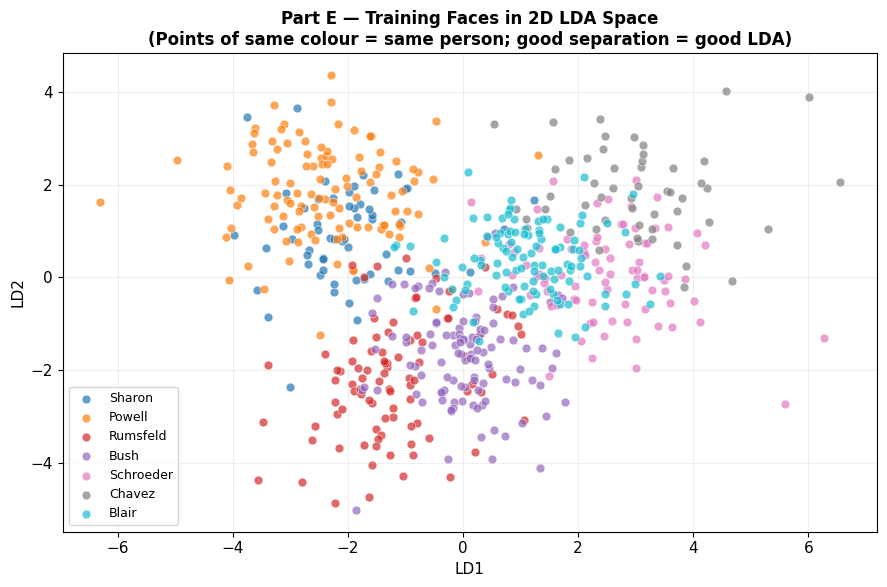

In [24]:
# E3 — Visualize 2D LDA projection
fig, ax = plt.subplots(figsize=(9, 6))
palette = plt.cm.tab10(np.linspace(0, 0.9, n_classes))

for cls_idx in range(n_classes):
    mask = y_train == cls_idx
    ax.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
               label=names[cls_idx].split()[-1], alpha=0.7, s=40,
               color=palette[cls_idx], edgecolors='white', linewidth=0.5)

ax.set_title('Part E — Training Faces in 2D LDA Space\n'
             '(Points of same colour = same person; good separation = good LDA)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('LD1', fontsize=11)
ax.set_ylabel('LD2', fontsize=11)
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


LDA + k-NN (k=1): 76.7%
LDA + k-NN (k=3): 79.1%
LDA + k-NN (k=5): 80.6%


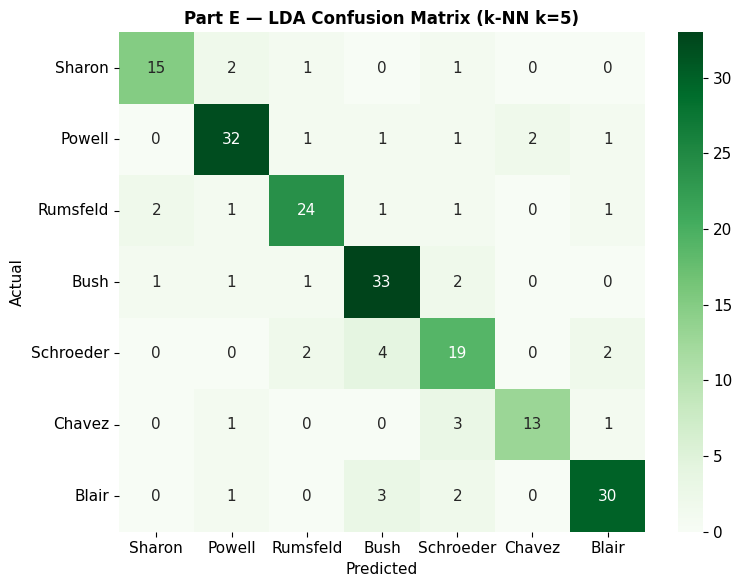

In [25]:
# E4 — k-NN classification in LDA space
lda_results = {}
for knn_k in [1, 3, 5]:
    knn_lda = KNeighborsClassifier(n_neighbors=knn_k)
    knn_lda.fit(X_train_lda, y_train)
    acc = accuracy_score(y_test, knn_lda.predict(X_test_lda))
    lda_results[knn_k] = acc
    print(f'LDA + k-NN (k={knn_k}): {acc*100:.1f}%')

best_lda_k = max(lda_results, key=lda_results.get)
best_lda_acc = lda_results[best_lda_k]

# Confusion matrix for best LDA config
knn_lda_best = KNeighborsClassifier(n_neighbors=best_lda_k)
knn_lda_best.fit(X_train_lda, y_train)
y_pred_lda = knn_lda_best.predict(X_test_lda)

cm_lda = confusion_matrix(y_test, y_pred_lda)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Greens',
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_title(f'Part E — LDA Confusion Matrix (k-NN k={best_lda_k})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()


#### 📝 Part E — Conceptual Questions

**Q9.** Why can LDA extract **at most C−1** discriminant components?  
*(Hint: Think about the rank of the between-class scatter matrix $S_B$.)*


**A9.** *(Write your answer here)*

...


**Q10.** Why does LDA often outperform PCA for *classification* tasks?  
*(Hint: PCA maximises variance — but is variance always the same as separability?)*


**A10.** *(Write your answer here)*

...


---
## Part F — PCA vs. LDA Comparison

> **Goal:** Put it all together in a single structured comparison.

📖 [PCA vs LDA — Towards Data Science](https://towardsdatascience.com/lda-is-highly-effective-than-pca-for-dimensionality-reduction-in-classification-datasets-4489eade632/)


In [26]:
# F1 — Comparison table
comparison_data = {
    'Method': [
        'Raw Pixels + k-NN',
        f'PCA ({best_comp} components) + k-NN',
        f'PCA ({n_pca_for_lda}) → LDA ({n_classes-1}) + k-NN'
    ],
    'Accuracy (%)': [
        round(baseline_acc * 100, 1),
        round(best_acc * 100, 1),
        round(best_lda_acc * 100, 1)
    ],
    'Output Dimensions': [
        n_features,
        best_comp,
        n_classes - 1
    ],
    'Supervised': ['No', 'No (PCA only)', 'Yes (LDA uses labels)'],
    'Optimises For': ['—', 'Variance', 'Class Separability']
}

df_compare = pd.DataFrame(comparison_data)
print('\n' + '='*75)
print('Part F — Method Comparison Table')
print('='*75)
print(df_compare.to_string(index=False))
print('='*75)



Part F — Method Comparison Table
                     Method  Accuracy (%)  Output Dimensions            Supervised      Optimises For
          Raw Pixels + k-NN          46.6               2914                    No                  —
PCA (100 components) + k-NN          60.7                100         No (PCA only)           Variance
 PCA (100) → LDA (6) + k-NN          80.6                  6 Yes (LDA uses labels) Class Separability


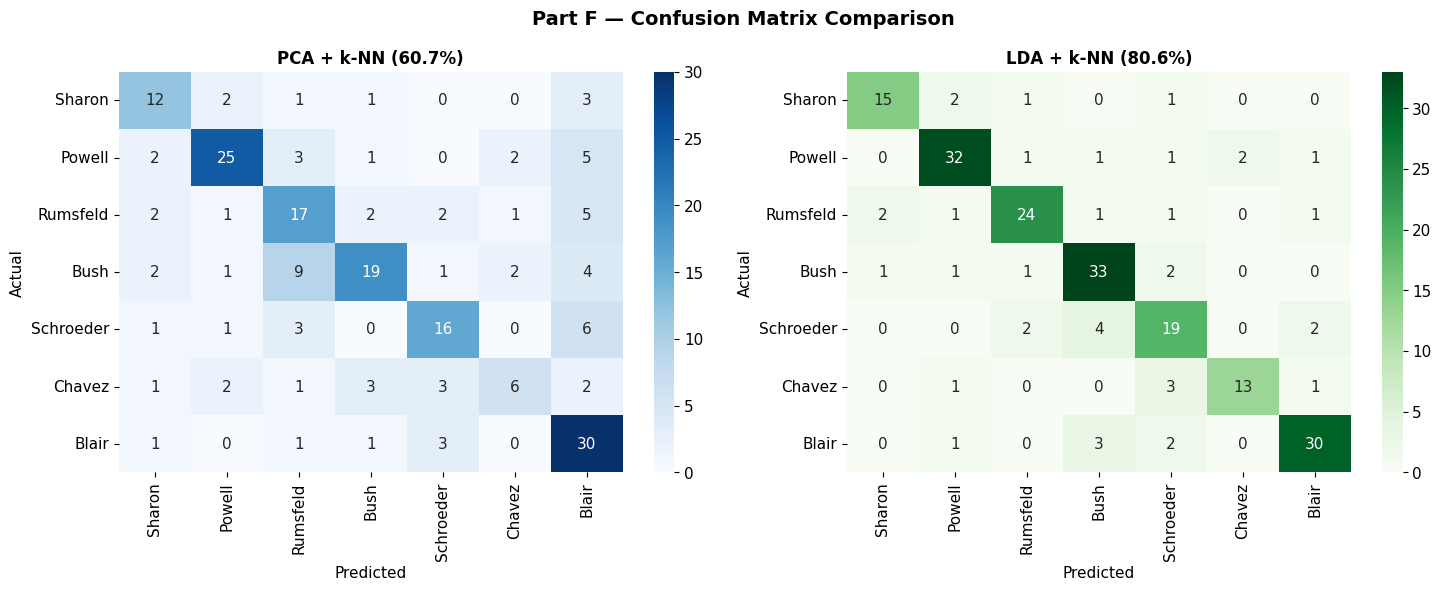

In [27]:
# F2 — Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, cm, title, cmap in zip(
    axes,
    [cm_pca, cm_lda],
    [f'PCA + k-NN ({best_acc*100:.1f}%)', f'LDA + k-NN ({best_lda_acc*100:.1f}%)'],
    ['Blues', 'Greens']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=short_names, yticklabels=short_names, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Part F — Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Final Reflection — Variance vs. Separability

Answer the following in a short paragraph each (3–5 sentences).


**Reflection 1 — Curse of Dimensionality & Practical Lessons**

From your experiments, what is the most important practical lesson you take away about working in high-dimensional spaces?  
How does dimensionality reduction change the geometry of the problem in a way that benefits k-NN?


**Your answer:**

...


**Reflection 2 — Variance vs. Discriminative Power**

PCA and LDA both project data to lower dimensions, but they optimise for entirely different objectives.  
In your own words, explain why maximising variance (PCA) is not the same as maximising class separability (LDA),  
and when each objective is more useful.


**Your answer:**

...


---
## Final Summary Table


In [28]:
# Auto-populate from your experiments
final_summary = pd.DataFrame({
    'Method'              : ['Raw Pixels + k-NN', f'PCA ({best_comp}c) + k-NN', 'PCA→LDA + k-NN'],
    'Clean Accuracy (%)'  : [round(baseline_acc*100,1), round(best_acc*100,1), round(best_lda_acc*100,1)],
    'Output Dims'         : [n_features, best_comp, n_classes-1],
    'Supervised'          : ['No', 'No', 'Yes'],
    'Key Strength'        : [
        'No reduction needed',
        'Good compression & denoising',
        'Maximum class separation'
    ]
})

print('=' * 90)
print('FINAL SUMMARY — FaceVault Face Recognition System')
print('=' * 90)
print(final_summary.to_string(index=False))
print('=' * 90)


FINAL SUMMARY — FaceVault Face Recognition System
           Method  Clean Accuracy (%)  Output Dims Supervised                 Key Strength
Raw Pixels + k-NN                46.6         2914         No          No reduction needed
PCA (100c) + k-NN                60.7          100         No Good compression & denoising
   PCA→LDA + k-NN                80.6            6        Yes     Maximum class separation
